In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.stats import norm
from matplotlib.ticker import MultipleLocator

In [7]:
# arr0 = np.load("D:\Chip2025\Chip2025_Testing\Python_Notebook\Tests\Data\BANK0_Delay_Sweep_DL_0_18_VB_20m.npy")
# arr1 = np.load("D:\Chip2025\Chip2025_Testing\Python_Notebook\Tests\Data\BANK0_Delay_Sweep_DL_18_72_VB_20m.npy")
# print(arr0.shape)
# #Voltage,Inputs,DL
# arr0 = arr0.reshape(11,int(arr0.shape[1]/18),18)
# arr1 = arr1.reshape(11,int(arr1.shape[1]/54),54)
# arr = np.concatenate((arr0,arr1),axis=2)
arr0 = np.load("..\Data\DEL_Calibration\BANK0_CALIB_DATA.npy")
print(arr0.shape)
arr0 = arr0.reshape(11,int(arr0.shape[1]/72),72)

arr1 = np.load("..\Data\DEL_Calibration\BANK1_CALIB_DATA.npy")
print(arr1.shape)
arr1 = arr1.reshape(11,int(arr1.shape[1]/72),72)

arr2 = np.load("..\Data\DEL_Calibration\BANK2_CALIB_DATA.npy")
print(arr2.shape)
arr2 = arr2.reshape(11,int(arr2.shape[1]/72),72)

arr3 = np.load("..\Data\DEL_Calibration\BANK3_CALIB_DATA.npy")
print(arr3.shape)
arr3 = arr3.reshape(11,int(arr3.shape[1]/72),72)

arr = np.concatenate((arr0,arr1,arr2,arr3),axis=2)
arr_diff =np.diff(arr, axis=1)
print(arr_diff.shape)
voltages = arr_diff.shape[0]
delaycells = arr_diff.shape[1]
delaylines = arr_diff.shape[2]

(11, 2376)
(11, 2376)
(11, 2376)
(11, 2376)
(11, 32, 288)


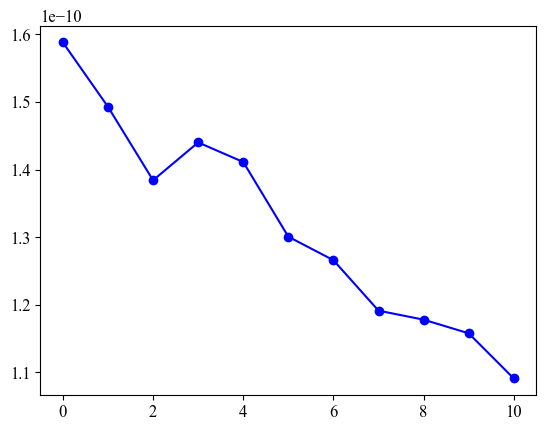

In [8]:
arr_vb = arr_diff[:,7,200]
plt.plot( arr_vb, marker='o', color='b', linestyle='-')

1.309162017144097e-10


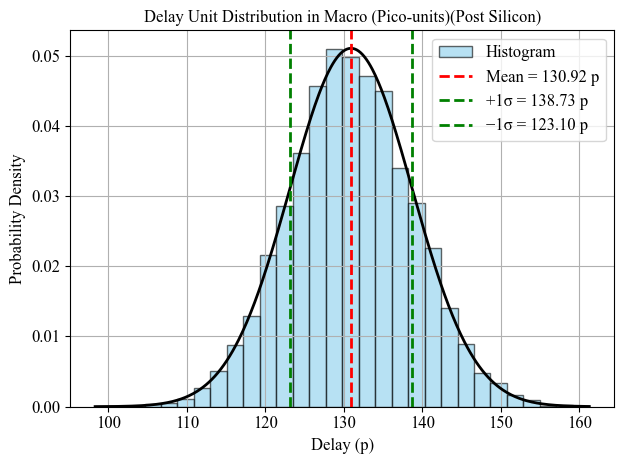

In [9]:
#780 is ideal voltage -> 
data_uncorrected = arr_diff[5].transpose()
data = arr_diff[5].flatten()
# Compute mean and std (in base units)
mean = np.mean(data)
mean_del = mean
print(mean)
std = np.std(data)
std_del = std
# Convert to pico-units
data_pico = data * 1e12
mean_pico = mean * 1e12
std_pico = std * 1e12
data_del = data_pico

# Plot histogram
count, bins, _ = plt.hist(data_pico, bins=30, density=True, alpha=0.6,
                          color='skyblue', edgecolor='black', label='Histogram')

# Overlay Gaussian curve
x = np.linspace(min(bins), max(bins), 500)
gaussian = norm.pdf(x, mean_pico, std_pico)
plt.plot(x, gaussian, color='black', linewidth=2)

# Plot mean line
plt.axvline(mean_pico, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_pico:.2f} p')

# Plot ±1σ lines
plt.axvline(mean_pico + std_pico, color='green', linestyle='--', linewidth=2,
            label=f'+1σ = {mean_pico + std_pico:.2f} p')
plt.axvline(mean_pico - std_pico, color='green', linestyle='--', linewidth=2,
            label=f'−1σ = {mean_pico - std_pico:.2f} p')

# Final touches
plt.title("Delay Unit Distribution in Macro (Pico-units)(Post Silicon)")
plt.xlabel("Delay (p)")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
#Compute error from mean at each voltage level

corrected_delay = np.zeros((delaylines,delaycells),dtype=np.float32)
corrected_voltage = np.zeros((delaylines,delaycells),dtype=np.float32)
for dl in range(delaylines):
    for dc in range(delaycells):
        min_error = 10
        for vol in range(voltages):
            delay = arr_diff[vol,dc,dl]
            error = abs(delay-mean_del)
            if error < min_error:
                min_error = error
                corrected_delay[dl,dc] = delay
                corrected_voltage[dl,dc] = vol
            

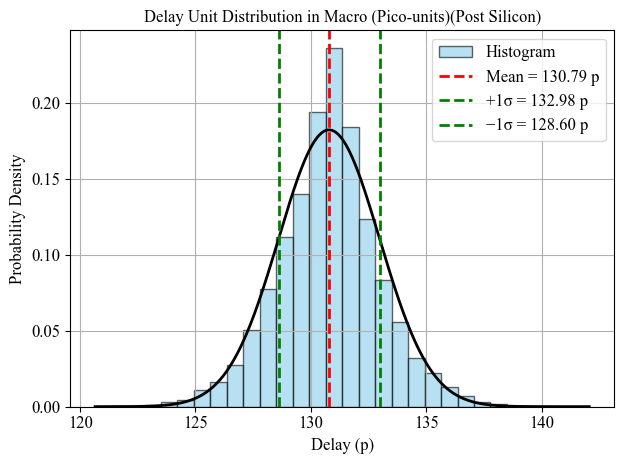

In [11]:
#780 is ideal voltage -> 
data_best_corrected = corrected_delay
data = corrected_delay.flatten()
# Compute mean and std (in base units)
mean = np.mean(data)
std = np.std(data)
mean_corrected = mean
std_corrcted = std
# Convert to pico-units
data_pico = data * 1e12
mean_pico = mean * 1e12
std_pico = std * 1e12
data_corrected = data_pico
# Plot histogram
count, bins, _ = plt.hist(data_pico, bins=30, density=True, alpha=0.6,
                          color='skyblue', edgecolor='black', label='Histogram')

# Overlay Gaussian curve
x = np.linspace(min(bins), max(bins), 500)
gaussian = norm.pdf(x, mean_pico, std_pico)
plt.plot(x, gaussian, color='black', linewidth=2)

# Plot mean line
plt.axvline(mean_pico, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_pico:.2f} p')

# Plot ±1σ lines
plt.axvline(mean_pico + std_pico, color='green', linestyle='--', linewidth=2,
            label=f'+1σ = {mean_pico + std_pico:.2f} p')
plt.axvline(mean_pico - std_pico, color='green', linestyle='--', linewidth=2,
            label=f'−1σ = {mean_pico - std_pico:.2f} p')

# Final touches
plt.title("Delay Unit Distribution in Macro (Pico-units)(Post Silicon)")
plt.xlabel("Delay (p)")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

(array([  27.,  121.,  441., 1033., 1660., 1871., 1677., 1120.,  710.,
         556.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

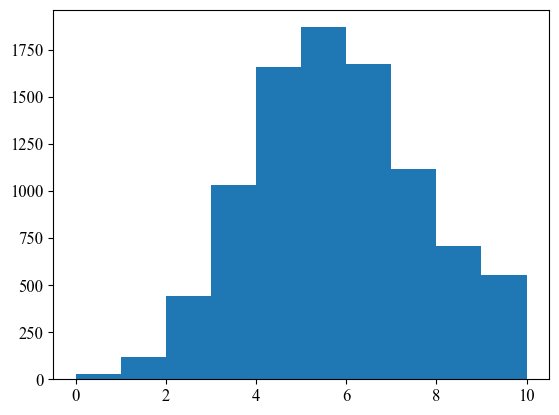

In [12]:
plt.hist(corrected_voltage.flatten())

In [13]:
corrected_delay = np.zeros((delaylines,delaycells),dtype=np.float32)
corrected_voltage = np.zeros((delaylines,delaycells),dtype=np.float32)
for dl in range(delaylines):
    for dc in range(delaycells):
        min_error = 10
        for vol in [3,4,6,9]:
            delay = arr_diff[vol,dc,dl]
            error = abs(delay-mean_del)
            if error < min_error:
                min_error = error
                corrected_delay[dl,dc] = delay
                corrected_voltage[dl,dc] = vol
#np.save("d:\Chip2025\Chip2025_Testing\Python_Notebook\Tests\Data\OSC_Calibration\VB_CALIB_VOLTAGES.npy",corrected_voltage)

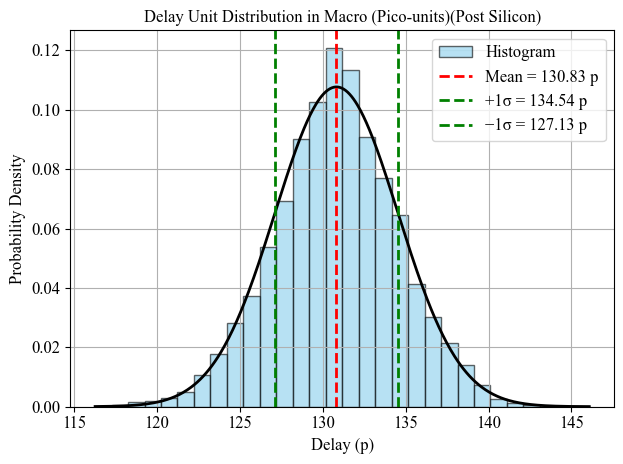

In [14]:
#780 is ideal voltage -> 
data_possible_corrected = corrected_delay
data = corrected_delay.flatten()
# Compute mean and std (in base units)
mean = np.mean(data)
std = np.std(data)
mean_poss = mean
std_poss = std
# Convert to pico-units
data_pico = data * 1e12
mean_pico = mean * 1e12
std_pico = std * 1e12
data_poss = data_pico
# Plot histogram
count, bins, _ = plt.hist(data_pico, bins=30, density=True, alpha=0.6,
                          color='skyblue', edgecolor='black', label='Histogram')

# Overlay Gaussian curve
x = np.linspace(min(bins), max(bins), 500)
gaussian = norm.pdf(x, mean_pico, std_pico)
plt.plot(x, gaussian, color='black', linewidth=2)

# Plot mean line
plt.axvline(mean_pico, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_pico:.2f} p')

# Plot ±1σ lines
plt.axvline(mean_pico + std_pico, color='green', linestyle='--', linewidth=2,
            label=f'+1σ = {mean_pico + std_pico:.2f} p')
plt.axvline(mean_pico - std_pico, color='green', linestyle='--', linewidth=2,
            label=f'−1σ = {mean_pico - std_pico:.2f} p')

# Final touches
plt.title("Delay Unit Distribution in Macro (Pico-units)(Post Silicon)")
plt.xlabel("Delay (p)")
plt.ylabel("Probability Density")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['font.family'] = 'Times New Roman'   # or 'Times New Roman', 'DejaVu Sans', etc.
mpl.rcParams['font.size'] = 12

# Axis-specific defaults
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12

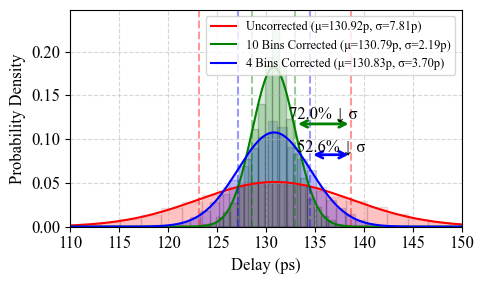

In [16]:
import numpy as np
from scipy.stats import norm

# Replace these with your actual values
# mean_del, mean_corrected, mean_poss = 120e-12, 118e-12, 119e-12
# std_del, std_corrcted, std_poss = 10e-12, 4e-12, 6e-12

labels = ['Uncorrected', '10 Bins Corrected', '4 Bins Corrected']
means_pico = [mean_del, mean_corrected, mean_poss] 
stds_pico = [std_del, std_corrcted, std_poss]

means = np.array(means_pico) * 1e12  # convert to pico
stds = np.array(stds_pico) * 1e12
x = np.linspace(min(means) - 4 * max(stds), max(means) + 4 * max(stds), 1000)

# Define new colors in requested order: red, green, blue
colors = ['red', 'green', 'blue']
perc_reduction = [(1 - s / stds[0]) * 100 for s in stds[1:]]

plt.figure(figsize=(5, 3))

count, bins, _ = plt.hist(data_del, bins=30, density=True, alpha=0.1,color='red', edgecolor='black')
count, bins, _ = plt.hist(data_poss, bins=30, density=True, alpha=0.15,color='blue', edgecolor='black')
count, bins, _ = plt.hist(data_corrected, bins=30, density=True, alpha=0.2,color='green', edgecolor='black')

for i, (mean, std, label, color) in enumerate(zip(means, stds, labels, colors)):
    pdf = norm.pdf(x, mean, std)
    plt.plot(x, pdf, label=f'{label} (μ={mean:.2f}p, σ={std:.2f}p)', color=color)
    plt.fill_between(x, pdf, alpha=0.15, color=color)

    # Draw ±1σ dashed lines
    plt.axvline(mean - std, color=color, linestyle='--', alpha=0.4)
    plt.axvline(mean + std, color=color, linestyle='--', alpha=0.4)

# Vertical base height for arrows (adjusted higher)
y_base = 2.3 * norm.pdf(means[0], means[0], stds[0])
y_base2 = y_base * 0.7

# Arrow: No Correction to Best Correction
plt.annotate(
    '', 
    xy=(means[0] + stds[0], y_base), 
    xytext=(means[1] + stds[1], y_base),
    arrowprops=dict(arrowstyle='<->', color='green', lw=2)
)
plt.text(
    (means[0] + stds[0] + means[1] + stds[1]) / 2, 
    y_base * 1.05, 
    f'{perc_reduction[0]:.1f}% ↓ σ', 
    ha='center', color='black', fontsize=12
)

# Arrow: No Correction to Possible Correction
plt.annotate(
    '', 
    xy=(means[0] + stds[0], y_base2), 
    xytext=(means[2] + stds[2], y_base2),
    arrowprops=dict(arrowstyle='<->', color='blue', lw=2)
)
plt.text(
    (means[0] + stds[0] + means[2] + stds[2]) / 2, 
    y_base2 * 1.05, 
    f'{perc_reduction[1]:.1f}% ↓ σ', 
    ha='center', color='black', fontsize=12
)

# Final plot formatting
plt.xlim(110, 150)
plt.xticks(range(110, 151, 5))
#plt.title('Delay Cell Correction (Measured)',fontsize=14)
plt.xlabel('Delay (ps)',fontsize=12)
plt.ylabel('Probability Density',fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=9)
plt.tight_layout()

plt.savefig("D:\ISSCC_26\Graphs\DelayCell_Correction.jpg",dpi=800, bbox_inches="tight", transparent=True)
plt.show()


In [17]:
print(data_uncorrected.shape,data_best_corrected.shape,data_possible_corrected.shape)
MAC_UNCORRECTED = np.cumsum(data_uncorrected,axis=1)
MAC_BEST_CORRECTED = np.cumsum(data_best_corrected,axis=1)
MAC_POSSIBLE_CORRECTED = np.cumsum(data_possible_corrected,axis=1)
STD_UNCORRECTED = np.std(MAC_UNCORRECTED,axis=0)
STD_CORRECTED = np.std(MAC_POSSIBLE_CORRECTED,axis=0)
print(np.mean(STD_UNCORRECTED),np.mean(STD_CORRECTED))

(288, 32) (288, 32) (288, 32)
2.566323746417202e-11 1.5083495e-11


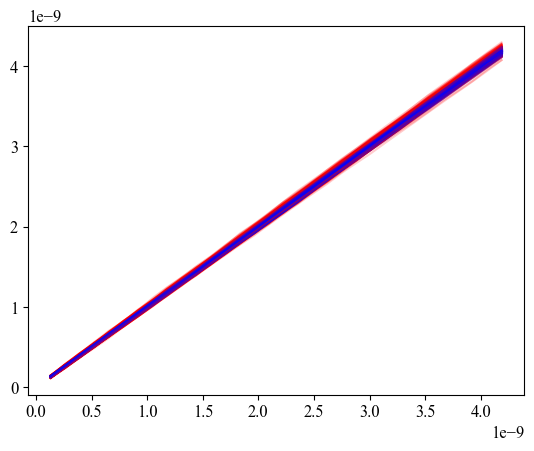

In [20]:
mu = 130.83e-12
mac_ideal = np.arange(mu,33*mu,mu)
for i in range(288):
    plt.plot(mac_ideal,MAC_UNCORRECTED[i],color = "red",alpha = 0.2)
    plt.plot(mac_ideal,MAC_POSSIBLE_CORRECTED[i],color = "Blue",alpha = 0.5)
    #plt.plot(mac_ideal,MAC_BEST_CORRECTED[i],color = "green",alpha = 1)

#plt.plot(MAC_BEST_CORRECTED)
#plt.plot(MAC_POSSIBLE_CORRECTED)

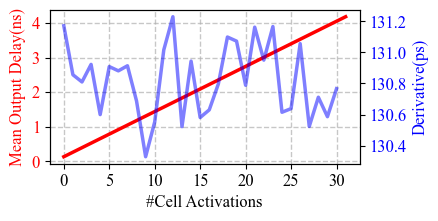

In [18]:
MEAN_MAC_CORRECTED = np.mean(MAC_POSSIBLE_CORRECTED,axis=0)*(10**9)
Derivative = np.diff(MEAN_MAC_CORRECTED)*(1000)

fig, ax1 = plt.subplots(figsize=(4, 2))

# First plot (left y-axis)
ax1.plot(MEAN_MAC_CORRECTED, color="r",linewidth=2.5)
ax1.set_xlabel("#Cell Activations",fontsize = 12)
ax1.set_ylabel("Mean Output Delay(ns)", color="r",fontsize = 12)
ax1.tick_params(axis="y", labelcolor="r")
#ax1.set_ylim(0, 140.8)
ax1.yaxis.set_major_locator(MultipleLocator(1))

# Second plot (right y-axis)
ax2 = ax1.twinx()
ax2.plot( Derivative, color="b",alpha=0.5,linewidth=2.5)
ax2.set_ylabel("Derivative(ps)", color="b",fontsize = 12)
ax2.tick_params(axis="y", labelcolor="b")
#ax2.set_ylim(0, 2.2)
ax2.yaxis.set_major_locator(MultipleLocator(0.2))



plt.xticks(range(0, 31,5)) 
# Optional: title
#plt.title("Analog Linearity (Measured Time-Domain)")
ax1.grid(True, which='major', linestyle='--', linewidth=1, alpha=0.7)
ax1.grid(True, which='minor', linestyle=':', linewidth=1, alpha=0.5)
plt.savefig("D:\ISSCC_26\Graphs\Analog_Linearity.jpg", dpi=800, bbox_inches="tight")
plt.show()

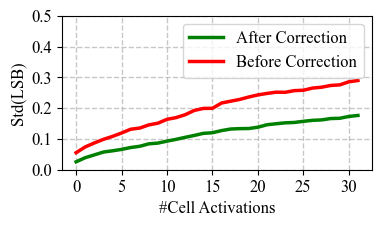

In [21]:
x_axis = np.arange(0,32,1)
fig, ax = plt.subplots(figsize=(4, 2))
plt.plot(x_axis,STD_CORRECTED/mu,label = "After Correction",color = "g",linewidth=2.5)
plt.plot(x_axis,STD_UNCORRECTED/mu, label = "Before Correction",color = "r",linewidth=2.5)
#plt.title("Analog MAC Variations (Measured Time-Domain)")
plt.ylabel("Std(LSB)",fontsize = 12)
plt.xlabel("#Cell Activations",fontsize = 12)
plt.ylim(0,0.5)
plt.xticks(range(0, 31,5))
plt.grid(True)
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.grid(True, which='major', linestyle='--', linewidth=1, alpha=0.7)
ax.grid(True, which='minor', linestyle=':', linewidth=1, alpha=0.5)
plt.legend() 
plt.savefig("D:\ISSCC_26\Graphs\STD_Corrections.jpg", dpi=800, bbox_inches="tight")


In [16]:
HW_MODEL_TD_DEL = np.zeros((64,4,32),dtype=np.float32)
Refline_NDX = [4,13,22,31,40,49,58,67]
print(data_possible_corrected.shape)
k = 0
m = 0
for dl in range(72*4):
    if np.floor(dl/72) == 0: #BANK0
        bank = 0
        reversed = True
    if np.floor(dl/72) == 1: #BANK1
        bank = 1
        reversed = False
    if np.floor(dl/72) == 2: #BANK2
        bank = 2
        reversed = True
    if np.floor(dl/72) == 3: #BANK3
        bank = 3
        reversed = False
    k = dl%72
    if k not in Refline_NDX:
        if not reversed:
            HW_MODEL_TD_DEL[m%64,bank] = data_possible_corrected[dl]/mu
        else:
            HW_MODEL_TD_DEL[m%64,bank] = data_possible_corrected[dl,::-1]/mu
        m = m+1
HW_MODEL_TD_DEL = np.repeat(HW_MODEL_TD_DEL, 8, axis=2)


(288, 32)


In [17]:

print(HW_MODEL_TD_DEL[0,0].sum())
#np.save("d:\Chip2025\Chip2025_Testing\Python_Notebook\Tests\Data\Hardware_Model\HW_MODEL_TD_DEL.npy",HW_MODEL_TD_DEL)

251.33472
